# FocalLoss Alpha Sweep: Results

Analyzes `models/alpha_sweep/results.json`, produced by
`scripts/sweep_alpha.py` -- 5 full training runs on the full-scale
(v2) dataset (5,078 train / 980 val samples), identical in every
hyperparameter except FocalLoss's `alpha`: 0.1, 0.25 (project
default), 0.5, 0.75, 0.9.

**Why this sweep exists**: `CLAUDE.md`'s "Inference + sanity check"
section claimed modest positive-cell confidence "traces directly to
alpha=0.25 ... down-weighting the positive class" and that fixing it
would need "a lower alpha." But `training.FocalLoss`'s actual formula
weights the positive class's loss by `alpha` itself
(`alpha_t = alpha * targets + (1 - alpha) * (1 - targets)`) -- so a
*lower* alpha should down-weight positives *further*, not less. That
claim looked backwards. Rather than trust the old note or intuition,
this sweep tests both directions and lets the real held-out numbers
decide.

## 1. Setup and Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tornado_predictor.inference import load_checkpoint, predict_proba
from tornado_predictor.training import DenseGridDataset

REPO_ROOT = Path.cwd().parent
MODELS = REPO_ROOT / "models"
DATA = REPO_ROOT / "data" / "processed"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"


In [2]:
results = json.loads((MODELS / "alpha_sweep" / "results.json").read_text())
df = pd.DataFrame(results).sort_values("alpha").reset_index(drop=True)
df[["alpha", "final_train_loss", "final_val_loss", "mean_proba_positive", "mean_proba_negative",
    "pooled_ratio", "cohens_d", "miss_rate", "per_sample_ratio_median", "elapsed_sec"]]

,alpha,final_train_loss,final_val_loss,mean_proba_positive,mean_proba_negative,pooled_ratio,cohens_d,miss_rate,per_sample_ratio_median,elapsed_sec
0,0.10,0.000078,0.000060,0.082201,0.005084,16.168339,2.320398,0.033281,12.862019,769.639595
1,0.25,0.000162,0.000125,0.119529,0.007835,15.255530,2.486004,0.025357,12.476979,766.269028
2,0.50,0.000269,0.000203,0.164888,0.015116,10.908521,2.857272,0.020602,9.676698,741.618897
3,0.75,0.000307,0.000240,0.225198,0.014926,15.087517,2.717645,0.028526,12.539667,718.691800
4,0.90,0.000279,0.000224,0.308236,0.028085,10.975067,3.081299,0.017433,9.852403,716.462527


## 2. Loss Curves Across Alpha

All 5 runs used identical data, architecture, epochs (50), and seed --
alpha is the only thing that changed.

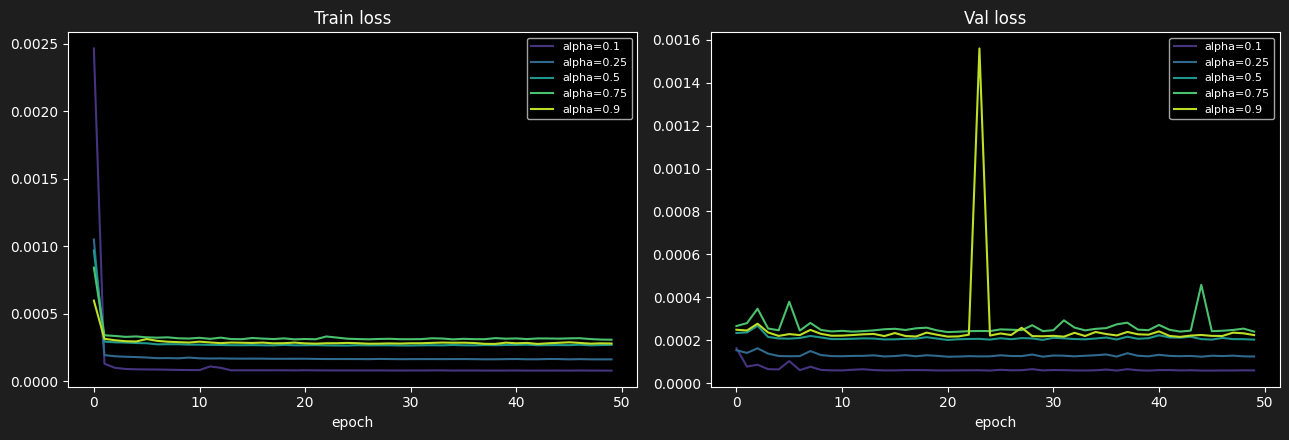

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(df)))

for color, row in zip(cmap, df.itertuples()):
    axes[0].plot(row.loss_history, color=color, label=f"alpha={row.alpha}")
    axes[1].plot(row.val_loss_history, color=color, label=f"alpha={row.alpha}")

axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].legend(fontsize=8)
axes[1].set_title("Val loss")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Absolute loss isn't directly comparable across alpha values -- `alpha`
rescales the loss itself, so a "lower loss" doesn't mean "better
model" here. It's included for completeness (all runs converge
smoothly, no training instability at any alpha) but the real
comparison is the held-out separation metrics below, computed
independently of the loss scale.

## 3. Resolving the Direction Question: Does Higher or Lower Alpha Win?

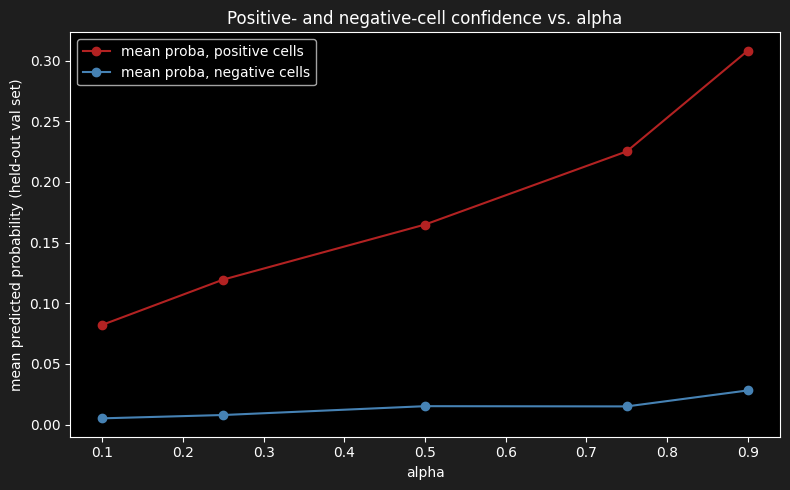

 alpha  mean_proba_positive  mean_proba_negative
  0.10             0.082201             0.005084
  0.25             0.119529             0.007835
  0.50             0.164888             0.015116
  0.75             0.225198             0.014926
  0.90             0.308236             0.028085


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["alpha"], df["mean_proba_positive"], marker="o", color="firebrick", label="mean proba, positive cells")
ax.plot(df["alpha"], df["mean_proba_negative"], marker="o", color="steelblue", label="mean proba, negative cells")
ax.set_xlabel("alpha")
ax.set_ylabel("mean predicted probability (held-out val set)")
ax.set_title("Positive- and negative-cell confidence vs. alpha")
ax.legend()
plt.tight_layout()
plt.show()

print(df[["alpha", "mean_proba_positive", "mean_proba_negative"]].to_string(index=False))

**Resolved, with real data**: `mean_proba_positive` rises monotonically
with alpha (0.082 at alpha=0.1 -> 0.308 at alpha=0.9) -- increasing
alpha pushes positive-cell confidence *up*, exactly as the FocalLoss
formula predicts (`alpha_t = alpha` for the positive class) and
exactly the opposite of what the old CLAUDE.md/docstring note claimed
("expect to need a lower alpha"). That note was wrong; it's corrected
in `training.py` and `CLAUDE.md` alongside this notebook.

The catch: `mean_proba_negative` also rises with alpha (0.005 ->
0.028) -- there's no free lunch, negative cells get pushed up too.
What matters is whether *separation* improves faster than the
negative-side cost grows, which the next section checks directly.

## 4. Does Separation Actually Improve? (the metric that matters)

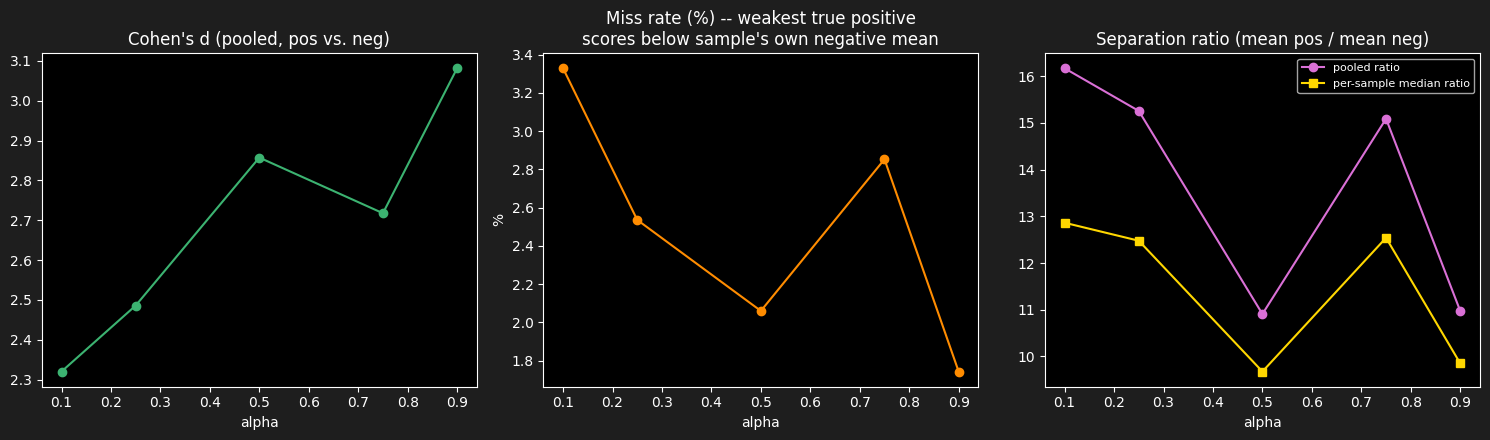

 alpha  cohens_d  miss_rate  pooled_ratio  per_sample_ratio_median
  0.10  2.320398   0.033281     16.168339                12.862019
  0.25  2.486004   0.025357     15.255530                12.476979
  0.50  2.857272   0.020602     10.908521                 9.676698
  0.75  2.717645   0.028526     15.087517                12.539667
  0.90  3.081299   0.017433     10.975067                 9.852403


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(df["alpha"], df["cohens_d"], marker="o", color="mediumseagreen")
axes[0].set_title("Cohen's d (pooled, pos vs. neg)")
axes[0].set_xlabel("alpha")

axes[1].plot(df["alpha"], df["miss_rate"] * 100, marker="o", color="darkorange")
axes[1].set_title("Miss rate (%) -- weakest true positive\nscores below sample's own negative mean")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("%")

axes[2].plot(df["alpha"], df["pooled_ratio"], marker="o", label="pooled ratio", color="orchid")
axes[2].plot(df["alpha"], df["per_sample_ratio_median"], marker="s", label="per-sample median ratio", color="gold")
axes[2].set_title("Separation ratio (mean pos / mean neg)")
axes[2].set_xlabel("alpha")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(df[["alpha", "cohens_d", "miss_rate", "pooled_ratio", "per_sample_ratio_median"]].to_string(index=False))

Three different ways of measuring "separation," three somewhat
different pictures:

- **Cohen's d** (accounts for spread, not just means) climbs from 2.32
  (alpha=0.1) to a peak of **3.08 at alpha=0.9** -- the strongest, most
  distributionally-robust metric, and it favors *higher* alpha almost
  monotonically (small dip at 0.75).
- **Miss rate** (the most practically meaningful: how often does the
  model fail completely on an active sample) also favors higher alpha:
  3.3% at alpha=0.1 down to **1.7% at alpha=0.9**, its best value.
- **Raw ratio metrics** (pooled and per-sample median) are noisier and
  *not* monotonic -- alpha=0.5 has the worst ratio (10.9x pooled) despite
  a strong Cohen's d (2.86), because both positive and negative means
  grow together and a simple ratio doesn't account for distribution
  spread the way Cohen's d does. This is a reminder that a raw
  mean-ratio is a weaker metric than it looks; Cohen's d and miss rate
  are more trustworthy here.

**Two of three metrics -- and the more rigorous two -- point toward
higher alpha (0.75-0.9) outperforming the project's current default of
0.25.**

## 5. Visual Check: Same Val Sample, Low vs. High Alpha

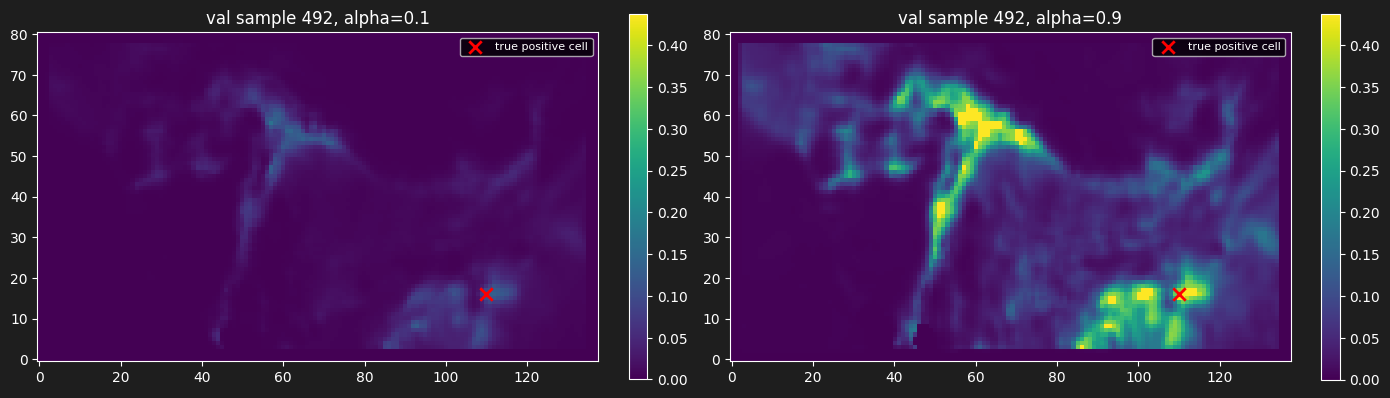

alpha=0.1: proba at true positive cells = [0.11996295]
alpha=0.9: proba at true positive cells = [0.43766904]


In [6]:
val_ds = DenseGridDataset(str(DATA / "training_dataset_val_full.nc"))
active_idx = np.where(val_ds.is_active)[0]
sample_idx = active_idx[len(active_idx) // 2]  # a representative active sample, not cherry-picked
X, y = val_ds[sample_idx]

low_model, _ = load_checkpoint(str(MODELS / "alpha_sweep" / "tornado_cnn_alpha_0.1.pt"))
high_model, _ = load_checkpoint(str(MODELS / "alpha_sweep" / "tornado_cnn_alpha_0.9.pt"))

proba_low = predict_proba(low_model, X)
proba_high = predict_proba(high_model, X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, proba, title in zip(axes, [proba_low, proba_high], ["alpha=0.1", "alpha=0.9"]):
    im = ax.imshow(proba, origin="lower", cmap="viridis", vmin=0, vmax=max(proba_low.max(), proba_high.max()))
    pos_rows, pos_cols = np.where(y > 0)
    ax.scatter(pos_cols, pos_rows, marker="x", s=80, c="red", linewidths=2, label="true positive cell")
    ax.set_title(f"val sample {sample_idx}, {title}")
    ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

print(f"alpha=0.1: proba at true positive cells = {proba_low[y > 0]}")
print(f"alpha=0.9: proba at true positive cells = {proba_high[y > 0]}")

## 6. Conclusion

- **The old "lower alpha" guidance was backwards** -- confirmed with
  real held-out data, not just re-reading the formula. Fixed in
  `training.py`'s `FocalLoss` docstring and `CLAUDE.md`.
- **Higher alpha (0.75-0.9) measurably improves held-out separation**
  on the two more rigorous metrics (Cohen's d, miss rate), at the cost
  of also raising negative-cell probabilities somewhat -- a real
  calibration tradeoff, not a free win.
- **alpha=0.9 is the best performer in this sweep** by both Cohen's d
  (3.08) and miss rate (1.7%). Nothing in this sweep tested values
  above 0.9 -- whether pushing further helps or starts hurting (e.g.
  by flooding negative-cell confidence) is unanswered here, a natural
  follow-up if this direction is pursued further.
- **This does not change the architecture** -- `TornadoCNN` is
  unchanged across all 5 runs (22,593 parameters, same as before).
  Widening the architecture is the next planned step, independent of
  this result.

Recommendation: adopt a higher default `alpha` (0.75 or 0.9) for
future runs, pending confirmation -- this notebook demonstrates the
evidence but the actual default change is a decision for discussion,
not made automatically here.